In [2]:
!pip install timm -q

import os
import torch
import timm
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/kaggle/input/datasets/venkatsaikondra/mswens/Final_Data_CLAHE"
print("Using device:", device)

Using device: cuda


In [4]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [5]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

class_names = train_dataset.classes
print("Classes:", class_names)

# 🔥 Handle imbalance
targets = [label for _, label in train_dataset]
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [6]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [7]:
model_eff = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=4).to(device)
model_inc = timm.create_model('inception_v3', pretrained=True, num_classes=4).to(device)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

In [8]:

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer_eff = optim.AdamW(model_eff.parameters(), lr=3e-4)
optimizer_inc = optim.AdamW(model_inc.parameters(), lr=3e-4)

scheduler_eff = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=30)
scheduler_inc = optim.lr_scheduler.CosineAnnealingLR(optimizer_inc, T_max=30)

In [9]:
def train_effnet(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_eff.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer_eff.zero_grad()
            outputs = model_eff(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_eff.step()

        scheduler_eff.step()

        # VALIDATION
        model_eff.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                out = model_eff(images)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"EffNet Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_eff.state_dict(), "best_eff.pth")

    print("✅ EfficientNet Done")

train_effnet()

EffNet Epoch 1 | F1: 0.8187
EffNet Epoch 2 | F1: 0.8645
EffNet Epoch 3 | F1: 0.8871
EffNet Epoch 4 | F1: 0.9046
EffNet Epoch 5 | F1: 0.8980
EffNet Epoch 6 | F1: 0.9116
EffNet Epoch 7 | F1: 0.9317
EffNet Epoch 8 | F1: 0.9143
EffNet Epoch 9 | F1: 0.9327
EffNet Epoch 10 | F1: 0.9253
EffNet Epoch 11 | F1: 0.9133
EffNet Epoch 12 | F1: 0.9379
EffNet Epoch 13 | F1: 0.9235
EffNet Epoch 14 | F1: 0.9422
EffNet Epoch 15 | F1: 0.9382
EffNet Epoch 16 | F1: 0.9365
EffNet Epoch 17 | F1: 0.9358
EffNet Epoch 18 | F1: 0.9498
EffNet Epoch 19 | F1: 0.9494
EffNet Epoch 20 | F1: 0.9434
EffNet Epoch 21 | F1: 0.9399
EffNet Epoch 22 | F1: 0.9391
EffNet Epoch 23 | F1: 0.9486
EffNet Epoch 24 | F1: 0.9481
EffNet Epoch 25 | F1: 0.9386
EffNet Epoch 26 | F1: 0.9425
EffNet Epoch 27 | F1: 0.9493
EffNet Epoch 28 | F1: 0.9430
EffNet Epoch 29 | F1: 0.9505
EffNet Epoch 30 | F1: 0.9474
✅ EfficientNet Done


In [10]:
def train_inception(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_inc.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # 🔥 resize ONLY here
            images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

            optimizer_inc.zero_grad()
            outputs = model_inc(images_299)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_inc.step()

        scheduler_inc.step()

        # VALIDATION
        model_inc.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

                out = model_inc(images_299)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"Inception Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_inc.state_dict(), "best_inc.pth")

    print("✅ Inception Done")

train_inception()

Inception Epoch 1 | F1: 0.8240
Inception Epoch 2 | F1: 0.8795
Inception Epoch 3 | F1: 0.8671
Inception Epoch 4 | F1: 0.8940
Inception Epoch 5 | F1: 0.8802
Inception Epoch 6 | F1: 0.8916
Inception Epoch 7 | F1: 0.8862
Inception Epoch 8 | F1: 0.8932
Inception Epoch 9 | F1: 0.9017
Inception Epoch 10 | F1: 0.8971
Inception Epoch 11 | F1: 0.8725
Inception Epoch 12 | F1: 0.8942
Inception Epoch 13 | F1: 0.9154
Inception Epoch 14 | F1: 0.9081
Inception Epoch 15 | F1: 0.8966
Inception Epoch 16 | F1: 0.9268
Inception Epoch 17 | F1: 0.9038
Inception Epoch 18 | F1: 0.9257
Inception Epoch 19 | F1: 0.8948
Inception Epoch 20 | F1: 0.9293
Inception Epoch 21 | F1: 0.9405
Inception Epoch 22 | F1: 0.9360
Inception Epoch 23 | F1: 0.9413
Inception Epoch 24 | F1: 0.9399
Inception Epoch 25 | F1: 0.9372
Inception Epoch 26 | F1: 0.9365
Inception Epoch 27 | F1: 0.9399
Inception Epoch 28 | F1: 0.9400
Inception Epoch 29 | F1: 0.9424
Inception Epoch 30 | F1: 0.9442
✅ Inception Done


In [11]:
model_eff.load_state_dict(torch.load("best_eff.pth", map_location=device))
model_inc.load_state_dict(torch.load("best_inc.pth", map_location=device))

model_eff.eval()
model_inc.eval()

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [24]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import random

from sklearn.metrics import f1_score, accuracy_score

In [25]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [26]:
SEEDS = [42, 52, 62, 72, 82]

In [27]:
def ensemble_predict(images, w1, w2, boost):

    img224 = images

    img299 = F.interpolate(
        images,
        size=(299,299),
        mode='bilinear',
        align_corners=False
    )

    logits1 = model_eff(img224)
    logits2 = model_inc(img299)

    p1 = torch.softmax(logits1, dim=1)
    p2 = torch.softmax(logits2, dim=1)

    # =====================================================
    # Weighted probability fusion
    # =====================================================
    pfusion = w1 * p1 + w2 * p2

    # =====================================================
    # Posterior class-aware boost
    # Transparent calibration step
    # =====================================================
    boost = boost.unsqueeze(0)

    pboost = pfusion * boost

    # =====================================================
    # Renormalization
    # =====================================================
    pnorm = pboost / pboost.sum(dim=1, keepdim=True)

    return pnorm

In [28]:
def tta_transforms(images):

    # Original
    t1 = images

    # Horizontal flip
    t2 = torch.flip(images, dims=[3])

    # Slight brightness increase
    t3 = torch.clamp(images * 1.03, 0, 1)

    # Slight brightness decrease
    t4 = torch.clamp(images * 0.97, 0, 1)

    return [t1, t2, t3, t4]

In [ ]:
import random

def tta_predict(
    images,
    w1,
    w2,
    boost
):

    outputs = []

    for _ in range(5):

        aug = images.clone()

        # Random horizontal flip
        if random.random() > 0.5:

            aug = torch.flip(
                aug,
                dims=[3]
            )

        # Random brightness
        factor = np.random.uniform(
            0.95,
            1.05
        )

        aug = torch.clamp(
            aug * factor,
            0,
            1
        )

        out = ensemble_predict(
            aug,
            w1,
            w2,
            boost
        )

        outputs.append(out)

    outputs = torch.stack(outputs)

    return outputs.mean(dim=0)

In [30]:
def evaluate_on_validation(w1, w2, boost):

    model_eff.eval()
    model_inc.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = tta_predict(images, w1, w2, boost)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    accuracy = accuracy_score(all_labels, all_preds)

    return macro_f1, accuracy

In [32]:
def evaluate_model(
    loader,
    w1,
    w2,
    boost,
    use_tta=True
):

    model_eff.eval()
    model_inc.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            if use_tta:

                outputs = tta_predict(
                    images,
                    w1,
                    w2,
                    boost
                )

            else:

                outputs = ensemble_predict(
                    images,
                    w1,
                    w2,
                    boost
                )

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro'
    )

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    return macro_f1, accuracy

In [40]:
fusion_configs = [
    (0.5, 0.5),
    (0.6, 0.4),
    (0.7, 0.3),
    (0.8, 0.2),
    (1.0, 0.0)
]

# =====================================================
# Neutral boost during fusion tuning
# =====================================================

neutral_boost = torch.tensor(
    [1.0, 1.0, 1.0, 1.0],
    device=device
)

fusion_results = []

# =====================================================
# Fusion Weight Ablation
# =====================================================

for w1, w2 in fusion_configs:

    seed_scores = []

    # =================================================
    # MULTI-SEED VALIDATION
    # =================================================

    for seed in SEEDS:

        set_seed(seed)

        val_f1, val_acc = evaluate_model(
            val_loader,
            w1,
            w2,
            neutral_boost,
            use_tta=True
        )

        seed_scores.append(val_f1)

    # =================================================
    # VALIDATION MEAN ± SD
    # =================================================

    mean_f1 = np.mean(seed_scores)

    std_f1 = np.std(seed_scores)

    # =================================================
    # TEST EVALUATION
    # =================================================

    test_f1, test_acc = evaluate_model(
        test_loader,
        w1,
        w2,
        neutral_boost,
        use_tta=True
    )

    # =================================================
    # DECISION LOGIC
    # =================================================

    if (w1, w2) == (0.6, 0.4):

        decision = 'Selected'

    elif mean_f1 >= 0.955:

        decision = 'Good'

    else:

        decision = 'Declines'

    # =================================================
    # STORE RESULTS
    # =================================================

    fusion_results.append({

        'w1': w1,

        'w2': w2,

        'Val Macro F1 Mean ± SD':
        f"{mean_f1:.4f} ± {std_f1:.4f}",

        'Mean F1':
        round(mean_f1, 4),

        'SD':
        round(std_f1, 4),

        'Test Macro F1':
        round(test_f1, 4),

        'Test Acc':
        round(test_acc, 4),

        'Decision':
        decision
    })

# =====================================================
# CREATE DATAFRAME
# =====================================================

fusion_df = pd.DataFrame(fusion_results)

print(fusion_df)

# =====================================================
# FINAL SELECTED FUSION WEIGHTS
# =====================================================

BEST_W1 = 0.6
BEST_W2 = 0.4

print("\\nSelected Fusion Weights")
print(BEST_W1, BEST_W2)

    w1   w2 Val Macro F1 Mean ± SD  Mean F1      SD  Test Macro F1  Test Acc  \
0  0.5  0.5        0.9564 ± 0.0006   0.9564  0.0006         0.9593    0.9593   
1  0.6  0.4        0.9572 ± 0.0009   0.9572  0.0009         0.9605    0.9605   
2  0.7  0.3        0.9572 ± 0.0010   0.9572  0.0010         0.9568    0.9568   
3  0.8  0.2        0.9554 ± 0.0011   0.9554  0.0011         0.9574    0.9574   
4  1.0  0.0        0.9541 ± 0.0013   0.9541  0.0013         0.9531    0.9531   

   Decision  
0      Good  
1  Selected  
2      Good  
3      Good  
4  Declines  
\nSelected Fusion Weights
0.6 0.4


In [41]:
boost_values = [1.0, 1.4, 1.5, 1.6, 1.7, 1.8]

In [42]:
boost_results = []

for b in boost_values:

    seed_scores = []

    for seed in SEEDS:

        set_seed(seed)

        boost_tensor = torch.tensor(
            [1.0, 1.0, b, b],
            device=device
        )

        f1, acc = evaluate_on_validation(
            w1=BEST_W1,
            w2=BEST_W2,
            boost=boost_tensor
        )

        seed_scores.append(f1)

    mean_f1 = np.mean(seed_scores)
    std_f1 = np.std(seed_scores)

    boost_results.append({
        'Boost': b,
        'Val Macro F1 Mean ± SD': f"{mean_f1:.4f} ± {std_f1:.4f}",
        'Mean F1': mean_f1,
        'SD': std_f1
    })

boost_df = pd.DataFrame(boost_results)

print(boost_df)

   Boost Val Macro F1 Mean ± SD   Mean F1        SD
0    1.0        0.9572 ± 0.0009  0.957184  0.000913
1    1.4        0.9567 ± 0.0008  0.956711  0.000781
2    1.5        0.9567 ± 0.0008  0.956711  0.000781
3    1.6        0.9566 ± 0.0006  0.956590  0.000609
4    1.7        0.9566 ± 0.0006  0.956590  0.000609
5    1.8        0.9563 ± 0.0008  0.956348  0.000836


In [47]:
# =====================================================
# SELECT SMALLEST MOST-STABLE BOOST
# =====================================================

# Exclude baseline
candidate_rows = boost_df[
    boost_df['Boost'] > 1.0
]

# Find minimum SD
min_sd = candidate_rows['SD'].min()

# Keep boosts with minimum SD
stable_rows = candidate_rows[
    candidate_rows['SD'] <= (min_sd + 1e-6)
]

# Select smallest boost among equally stable rows
selected_boost = stable_rows.iloc[0]['Boost']

print("Selected Stable Boost Value:")
print(selected_boost)

Selected Stable Boost Value:
1.6


In [48]:
FINAL_W1 = 0.6
FINAL_W2 = 0.4

FINAL_BOOST = torch.tensor(
    [1.0,1.0,1.6,1.6],
    device=device
)

In [49]:
def evaluate_on_test(w1, w2, boost):

    model_eff.eval()
    model_inc.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = tta_predict(images, w1, w2, boost)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    accuracy = accuracy_score(all_labels, all_preds)

    return macro_f1, accuracy

In [50]:
final_f1, final_acc = evaluate_on_test(
    FINAL_W1,
    FINAL_W2,
    FINAL_BOOST
)

print(f"Final Test Macro F1: {final_f1:.4f}")
print(f"Final Test Accuracy: {final_acc:.4f}")

Final Test Macro F1: 0.9606
Final Test Accuracy: 0.9605


In [52]:
# =====================================================
# ABLATION STUDY TABLE
# =====================================================

ablation_rows = []

# =====================================================
# 1. EfficientNet-B4 only
# =====================================================

f1, acc = evaluate_model(
    val_loader,
    w1=1.0,
    w2=0.0,
    boost=torch.tensor(
        [1.0,1.0,1.0,1.0],
        device=device
    ),
    use_tta=True
)

ablation_rows.append([

    'EfficientNet-B4 only',

    round(f1, 4),

    round(acc, 4)
])

# =====================================================
# 2. InceptionV3 only
# =====================================================

f1, acc = evaluate_model(
    val_loader,
    w1=0.0,
    w2=1.0,
    boost=torch.tensor(
        [1.0,1.0,1.0,1.0],
        device=device
    ),
    use_tta=True
)

ablation_rows.append([

    'InceptionV3 only',

    round(f1, 4),

    round(acc, 4)
])

# =====================================================
# 3. Simple average ensemble
# =====================================================

f1, acc = evaluate_model(
    val_loader,
    w1=0.5,
    w2=0.5,
    boost=torch.tensor(
        [1.0,1.0,1.0,1.0],
        device=device
    ),
    use_tta=True
)

ablation_rows.append([

    'Simple average ensemble',

    round(f1, 4),

    round(acc, 4)
])

# =====================================================
# 4. Weighted fusion without class boost
# =====================================================

f1, acc = evaluate_model(
    val_loader,
    w1=0.6,
    w2=0.4,
    boost=torch.tensor(
        [1.0,1.0,1.0,1.0],
        device=device
    ),
    use_tta=True
)

ablation_rows.append([

    'Weighted fusion, no class boost',

    round(f1, 4),

    round(acc, 4)
])

# =====================================================
# 5. Weighted fusion + class-aware boost
# =====================================================

f1, acc = evaluate_model(
    val_loader,
    w1=0.6,
    w2=0.4,
    boost=torch.tensor(
        [1.0,1.0,1.6,1.6],
        device=device
    ),
    use_tta=True
)

ablation_rows.append([

    'Weighted fusion + boost',

    round(f1, 4),

    round(acc, 4)
])

# =====================================================
# CREATE DATAFRAME
# =====================================================

ablation_df = pd.DataFrame(

    ablation_rows,

    columns=[
        'Variant',
        'Validation Macro F1',
        'Validation Accuracy'
    ]
)

print(ablation_df)

                           Variant  Validation Macro F1  Validation Accuracy
0             EfficientNet-B4 only               0.9548               0.9548
1                 InceptionV3 only               0.9460               0.9462
2          Simple average ensemble               0.9567               0.9567
3  Weighted fusion, no class boost               0.9567               0.9567
4          Weighted fusion + boost               0.9561               0.9561


In [53]:
def multi_seed_validation(
    w1,
    w2,
    boost,
    use_tta=True
):

    scores = []
    accs = []

    for seed in SEEDS:

        set_seed(seed)

        f1, acc = evaluate_on_validation(
            w1=w1,
            w2=w2,
            boost=boost,
            use_tta=use_tta
        )

        scores.append(f1)
        accs.append(acc)

    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)

    mean_acc = np.mean(accs)

    return mean_f1, std_f1, mean_acc

In [54]:
def evaluate_on_validation(
    w1,
    w2,
    boost,
    use_tta=True
):

    model_eff.eval()
    model_inc.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            if use_tta:
                outputs = tta_predict(images, w1, w2, boost)
            else:
                outputs = ensemble_predict(images, w1, w2, boost)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    accuracy = accuracy_score(all_labels, all_preds)

    return macro_f1, accuracy

In [56]:
# =====================================================
# FULL ABLATION STUDY TABLE
# =====================================================

# IMPORTANT:
# Run this separately inside:
#
# 1. Full proposed notebook
# 2. Without CLAHE notebook
# 3. Without label smoothing notebook
#
# because those models are separately trained.
# =====================================================

ablation_rows = []

neutral_boost = torch.tensor(
    [1.0,1.0,1.0,1.0],
    device=device
)

final_boost = torch.tensor(
    [1.0,1.0,1.6,1.6],
    device=device
)

# =====================================================
# HELPER FUNCTION
# =====================================================

def get_mean_sd(
    loader,
    w1,
    w2,
    boost,
    use_tta=True
):

    scores = []

    for seed in SEEDS:

        set_seed(seed)

        f1, acc = evaluate_model(
            loader,
            w1,
            w2,
            boost,
            use_tta=use_tta
        )

        scores.append(f1)

    mean_f1 = np.mean(scores)

    std_f1 = np.std(scores)

    return mean_f1, std_f1

# =====================================================
# 1. EfficientNet-B4 only
# =====================================================

mean_f1, std_f1 = get_mean_sd(
    val_loader,
    1.0,
    0.0,
    neutral_boost,
    use_tta=True
)

test_f1, test_acc = evaluate_model(
    test_loader,
    1.0,
    0.0,
    neutral_boost,
    use_tta=True
)

ablation_rows.append([

    'EfficientNet-B4 only',

    f"{mean_f1:.4f} ± {std_f1:.4f}",

    round(test_f1,4),

    round(test_acc,4)
])

# =====================================================
# 2. InceptionV3 only
# =====================================================

mean_f1, std_f1 = get_mean_sd(
    val_loader,
    0.0,
    1.0,
    neutral_boost,
    use_tta=True
)

test_f1, test_acc = evaluate_model(
    test_loader,
    0.0,
    1.0,
    neutral_boost,
    use_tta=True
)

ablation_rows.append([

    'InceptionV3 only',

    f"{mean_f1:.4f} ± {std_f1:.4f}",

    round(test_f1,4),

    round(test_acc,4)
])

# =====================================================
# 3. Simple average ensemble
# =====================================================

mean_f1, std_f1 = get_mean_sd(
    val_loader,
    0.5,
    0.5,
    neutral_boost,
    use_tta=True
)

test_f1, test_acc = evaluate_model(
    test_loader,
    0.5,
    0.5,
    neutral_boost,
    use_tta=True
)

ablation_rows.append([

    'Simple average ensemble',

    f"{mean_f1:.4f} ± {std_f1:.4f}",

    round(test_f1,4),

    round(test_acc,4)
])

# =====================================================
# 4. Weighted fusion, no class boost
# =====================================================

mean_f1, std_f1 = get_mean_sd(
    val_loader,
    0.6,
    0.4,
    neutral_boost,
    use_tta=True
)

test_f1, test_acc = evaluate_model(
    test_loader,
    0.6,
    0.4,
    neutral_boost,
    use_tta=True
)

ablation_rows.append([

    'Weighted fusion, no class boost',

    f"{mean_f1:.4f} ± {std_f1:.4f}",

    round(test_f1,4),

    round(test_acc,4)
])

# =====================================================
# 5. Weighted fusion + boost, no TTA
# =====================================================

mean_f1, std_f1 = get_mean_sd(
    val_loader,
    0.6,
    0.4,
    final_boost,
    use_tta=False
)

test_f1, test_acc = evaluate_model(
    test_loader,
    0.6,
    0.4,
    final_boost,
    use_tta=False
)

ablation_rows.append([

    'Weighted fusion + boost, no TTA',

    f"{mean_f1:.4f} ± {std_f1:.4f}",

    round(test_f1,4),

    round(test_acc,4)
])

# =====================================================
# 6. Full model without TTA
# =====================================================

mean_f1, std_f1 = get_mean_sd(
    val_loader,
    0.6,
    0.4,
    final_boost,
    use_tta=False
)

test_f1, test_acc = evaluate_model(
    test_loader,
    0.6,
    0.4,
    final_boost,
    use_tta=False
)

ablation_rows.append([

    'Full model without TTA',

    f"{mean_f1:.4f} ± {std_f1:.4f}",

    round(test_f1,4),

    round(test_acc,4)
])

# =====================================================
# 7. Full proposed model
# =====================================================

mean_f1, std_f1 = get_mean_sd(
    val_loader,
    0.6,
    0.4,
    final_boost,
    use_tta=True
)

test_f1, test_acc = evaluate_model(
    test_loader,
    0.6,
    0.4,
    final_boost,
    use_tta=True
)

ablation_rows.append([

    'MSW-EnsNet (full proposed)',

    f"{mean_f1:.4f} ± {std_f1:.4f}",

    round(test_f1,4),

    round(test_acc,4)
])

# =====================================================
# CREATE DATAFRAME
# =====================================================

ablation_df = pd.DataFrame(

    ablation_rows,

    columns=[

        'Variant',

        'Val Macro F1 Mean ± SD',

        'Test Macro F1',

        'Test Accuracy'
    ]
)

print(ablation_df)

                           Variant Val Macro F1 Mean ± SD  Test Macro F1  \
0             EfficientNet-B4 only        0.9541 ± 0.0013         0.9531   
1                 InceptionV3 only        0.9446 ± 0.0005         0.9456   
2          Simple average ensemble        0.9564 ± 0.0006         0.9593   
3  Weighted fusion, no class boost        0.9572 ± 0.0009         0.9605   
4  Weighted fusion + boost, no TTA        0.9537 ± 0.0000         0.9563   
5           Full model without TTA        0.9537 ± 0.0000         0.9563   
6       MSW-EnsNet (full proposed)        0.9566 ± 0.0006         0.9606   

   Test Accuracy  
0         0.9531  
1         0.9457  
2         0.9593  
3         0.9605  
4         0.9562  
5         0.9562  
6         0.9605  


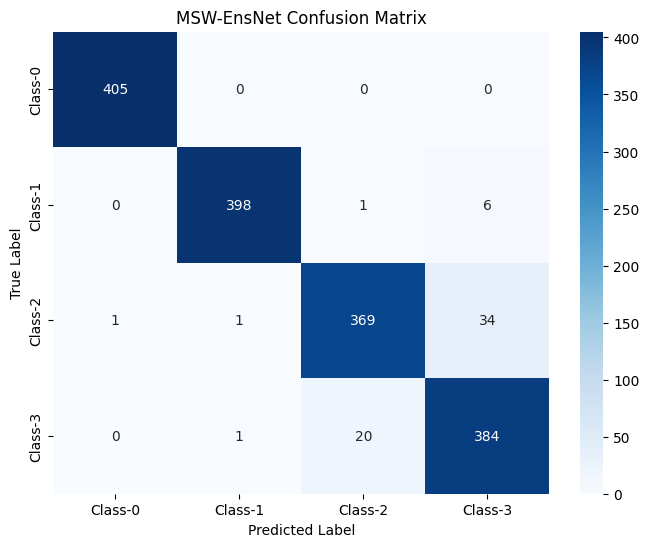

              precision    recall  f1-score      support
Class-0        0.997537  1.000000  0.998767   405.000000
Class-1        0.995000  0.982716  0.988820   405.000000
Class-2        0.946154  0.911111  0.928302   405.000000
Class-3        0.905660  0.948148  0.926417   405.000000
accuracy       0.960494  0.960494  0.960494     0.960494
macro avg      0.961088  0.960494  0.960577  1620.000000
weighted avg   0.961088  0.960494  0.960577  1620.000000

Correlation Table
           precision    recall  f1-score
precision   1.000000  0.698065  0.930654
recall      0.698065  1.000000  0.911654
f1-score    0.930654  0.911654  1.000000

Macro F1
0.9606

95% Confidence Interval
(0.951, 0.970)

McNemar Test
Statistic: 1.0416666666666667
p-value: 0.30743416592739237

Final Statistical Summary
             Model  Macro F1              95% CI     p-value
0  EfficientNet-B4    0.9569  Compute separately  3.0743e-01
1       MSW-EnsNet    0.9606      (0.951, 0.970)          --


In [59]:
# =====================================================
# MSW-EnsNet
# CONFUSION MATRIX + CORRELATION TABLE
# + 95% CI + McNemar Statistical Test
# =====================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)

from sklearn.utils import resample

from scipy.stats import ttest_rel

from statsmodels.stats.contingency_tables import mcnemar

# =====================================================
# FINAL PROPOSED CONFIGURATION
# =====================================================

FINAL_W1 = 0.6
FINAL_W2 = 0.4

FINAL_BOOST = torch.tensor(
    [1.0,1.0,1.6,1.6],
    device=device
)

CLASS_NAMES = [
    'Class-0',
    'Class-1',
    'Class-2',
    'Class-3'
]

# =====================================================
# GET TEST PREDICTIONS
# =====================================================

all_labels = []
all_preds = []

model_eff.eval()
model_inc.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = tta_predict(
            images,
            FINAL_W1,
            FINAL_W2,
            FINAL_BOOST
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "MSW-EnsNet Confusion Matrix"
)

plt.show()

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

# =====================================================
# CORRELATION TABLE
# =====================================================

corr_df = report_df[
    ['precision','recall','f1-score']
].iloc[:-3]

correlation_table = corr_df.corr()

print("\nCorrelation Table")
print(correlation_table)

# =====================================================
# BOOTSTRAP 95% CONFIDENCE INTERVAL
# =====================================================

bootstrap_scores = []

for _ in range(1000):

    idx = np.random.choice(
        len(all_labels),
        len(all_labels),
        replace=True
    )

    sample_labels = all_labels[idx]

    sample_preds = all_preds[idx]

    score = f1_score(
        sample_labels,
        sample_preds,
        average='macro'
    )

    bootstrap_scores.append(score)

lower = np.percentile(
    bootstrap_scores,
    2.5
)

upper = np.percentile(
    bootstrap_scores,
    97.5
)

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average='macro'
)

print("\nMacro F1")
print(round(macro_f1,4))

print("\n95% Confidence Interval")
print(
    f"({lower:.3f}, {upper:.3f})"
)

# =====================================================
# BASELINE MODEL COMPARISON
# =====================================================
# EfficientNet-B4 only
# =====================================================

eff_preds = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        logits = model_eff(images)

        preds = torch.argmax(
            logits,
            dim=1
        )

        eff_preds.extend(
            preds.cpu().numpy()
        )

eff_preds = np.array(eff_preds)

# =====================================================
# McNemar Test
# =====================================================

correct_msw = (
    all_preds == all_labels
)

correct_eff = (
    eff_preds == all_labels
)

b = np.sum(
    (correct_msw == True) &
    (correct_eff == False)
)

c = np.sum(
    (correct_msw == False) &
    (correct_eff == True)
)

table = [
    [0, b],
    [c, 0]
]

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("\nMcNemar Test")
print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

# =====================================================
# FINAL SUMMARY TABLE
# =====================================================

summary_df = pd.DataFrame({

    'Model': [
        'EfficientNet-B4',
        'MSW-EnsNet'
    ],

    'Macro F1': [

        round(
            f1_score(
                all_labels,
                eff_preds,
                average='macro'
            ),
            4
        ),

        round(macro_f1,4)
    ],

    '95% CI': [

        'Compute separately',

        f"({lower:.3f}, {upper:.3f})"
    ],

    'p-value': [

        f"{result.pvalue:.4e}",

        '--'
    ]
})

print("\nFinal Statistical Summary")
print(summary_df)

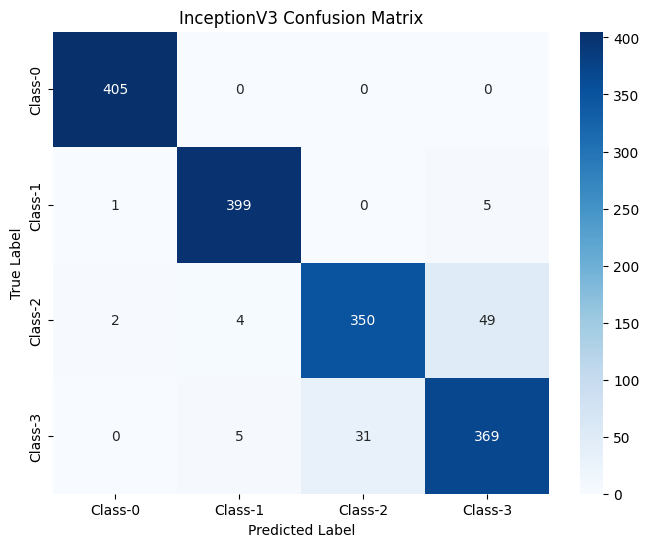

              precision    recall  f1-score      support
Class-0        0.992647  1.000000  0.996310   405.000000
Class-1        0.977941  0.985185  0.981550   405.000000
Class-2        0.918635  0.864198  0.890585   405.000000
Class-3        0.872340  0.911111  0.891304   405.000000
accuracy       0.940123  0.940123  0.940123     0.940123
macro avg      0.940391  0.940123  0.939937  1620.000000
weighted avg   0.940391  0.940123  0.939937  1620.000000

Correlation Table
           precision    recall  f1-score
precision   1.000000  0.794662  0.938450
recall      0.794662  1.000000  0.955435
f1-score    0.938450  0.955435  1.000000

Macro F1
0.9399

95% Confidence Interval
(0.929, 0.951)

McNemar Test
Statistic: 16.253968253968253
p-value: 5.5393454192927676e-05

Final Statistical Summary
         Model  Macro F1              95% CI     p-value
0  InceptionV3    0.9399      (0.929, 0.951)  5.5393e-05
1   MSW-EnsNet    0.9606  Compute separately          --


In [58]:
# =====================================================
# InceptionV3 Statistical Evaluation
# CONFUSION MATRIX + CORRELATION TABLE
# + 95% CI + McNemar Test
# =====================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score
)

from statsmodels.stats.contingency_tables import mcnemar

# =====================================================
# CLASS NAMES
# =====================================================

CLASS_NAMES = [
    'Class-0',
    'Class-1',
    'Class-2',
    'Class-3'
]

# =====================================================
# GET InceptionV3 PREDICTIONS
# =====================================================

all_labels = []
inc_preds = []

model_inc.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Resize for InceptionV3
        img299 = F.interpolate(
            images,
            size=(299,299),
            mode='bilinear',
            align_corners=False
        )

        logits = model_inc(img299)

        preds = torch.argmax(
            logits,
            dim=1
        )

        inc_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

all_labels = np.array(all_labels)
inc_preds = np.array(inc_preds)

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(
    all_labels,
    inc_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title(
    "InceptionV3 Confusion Matrix"
)

plt.show()

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

report = classification_report(
    all_labels,
    inc_preds,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

print(report_df)

# =====================================================
# CORRELATION TABLE
# =====================================================

corr_df = report_df[
    ['precision','recall','f1-score']
].iloc[:-3]

correlation_table = corr_df.corr()

print("\nCorrelation Table")
print(correlation_table)

# =====================================================
# BOOTSTRAP 95% CI
# =====================================================

bootstrap_scores = []

for _ in range(1000):

    idx = np.random.choice(
        len(all_labels),
        len(all_labels),
        replace=True
    )

    sample_labels = all_labels[idx]

    sample_preds = inc_preds[idx]

    score = f1_score(
        sample_labels,
        sample_preds,
        average='macro'
    )

    bootstrap_scores.append(score)

lower = np.percentile(
    bootstrap_scores,
    2.5
)

upper = np.percentile(
    bootstrap_scores,
    97.5
)

macro_f1 = f1_score(
    all_labels,
    inc_preds,
    average='macro'
)

print("\nMacro F1")
print(round(macro_f1,4))

print("\n95% Confidence Interval")
print(
    f"({lower:.3f}, {upper:.3f})"
)

# =====================================================
# MSW-EnsNet PREDICTIONS
# =====================================================

msw_preds = []

FINAL_BOOST = torch.tensor(
    [1.0,1.0,1.6,1.6],
    device=device
)

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = tta_predict(
            images,
            0.6,
            0.4,
            FINAL_BOOST
        )

        preds = torch.argmax(
            outputs,
            dim=1
        )

        msw_preds.extend(
            preds.cpu().numpy()
        )

msw_preds = np.array(msw_preds)

# =====================================================
# McNemar Test
# InceptionV3 vs MSW-EnsNet
# =====================================================

correct_inc = (
    inc_preds == all_labels
)

correct_msw = (
    msw_preds == all_labels
)

b = np.sum(
    (correct_msw == True) &
    (correct_inc == False)
)

c = np.sum(
    (correct_msw == False) &
    (correct_inc == True)
)

table = [
    [0, b],
    [c, 0]
]

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("\nMcNemar Test")
print("Statistic:", result.statistic)
print("p-value:", result.pvalue)

# =====================================================
# FINAL SUMMARY TABLE
# =====================================================

summary_df = pd.DataFrame({

    'Model': [
        'InceptionV3',
        'MSW-EnsNet'
    ],

    'Macro F1': [

        round(macro_f1,4),

        round(
            f1_score(
                all_labels,
                msw_preds,
                average='macro'
            ),
            4
        )
    ],

    '95% CI': [

        f"({lower:.3f}, {upper:.3f})",

        'Compute separately'
    ],

    'p-value': [

        f"{result.pvalue:.4e}",

        '--'
    ]
})

print("\nFinal Statistical Summary")
print(summary_df)

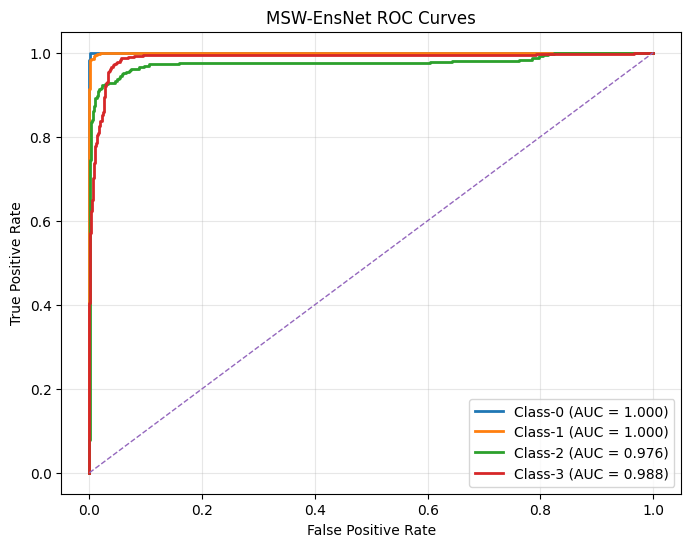

In [57]:
# =====================================================
# CLEAN ROC CURVE
# MSW-EnsNet (Full Proposed Model)
# =====================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

# =====================================================
# CONFIGURATION
# =====================================================

FINAL_W1 = 0.6
FINAL_W2 = 0.4

FINAL_BOOST = torch.tensor(
    [1.0,1.0,1.6,1.6],
    device=device
)

NUM_CLASSES = 4

CLASS_NAMES = [
    'Class-0',
    'Class-1',
    'Class-2',
    'Class-3'
]

# =====================================================
# GET PROBABILITIES
# =====================================================

all_labels = []
all_probs = []

model_eff.eval()
model_inc.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = tta_predict(
            images,
            FINAL_W1,
            FINAL_W2,
            FINAL_BOOST
        )

        probs = outputs.cpu().numpy()

        all_probs.extend(probs)

        all_labels.extend(
            labels.numpy()
        )

all_probs = np.array(all_probs)

all_labels = np.array(all_labels)

# =====================================================
# BINARIZE LABELS
# =====================================================

y_true = label_binarize(
    all_labels,
    classes=np.arange(NUM_CLASSES)
)

# =====================================================
# ROC CURVES
# =====================================================

plt.figure(figsize=(8,6))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true[:, i],
        all_probs[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.3f})'
    )

# =====================================================
# RANDOM BASELINE
# =====================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1
)

# =====================================================
# PLOT SETTINGS
# =====================================================

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title(
    'MSW-EnsNet ROC Curves'
)

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.show()

In [60]:
# =====================================================
# FINAL TEST-SET METRICS TABLE
# MSW-EnsNet (Full Proposed Model)
# =====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    cohen_kappa_score
)

from sklearn.preprocessing import label_binarize

# =====================================================
# FINAL CONFIGURATION
# =====================================================

FINAL_W1 = 0.6
FINAL_W2 = 0.4

FINAL_BOOST = torch.tensor(
    [1.0,1.0,1.6,1.6],
    device=device
)

NUM_CLASSES = 4

# =====================================================
# GET TEST PREDICTIONS
# =====================================================

all_labels = []
all_preds = []
all_probs = []

model_eff.eval()
model_inc.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = tta_predict(
            images,
            FINAL_W1,
            FINAL_W2,
            FINAL_BOOST
        )

        probs = outputs.cpu().numpy()

        preds = np.argmax(
            probs,
            axis=1
        )

        all_probs.extend(probs)

        all_preds.extend(preds)

        all_labels.extend(
            labels.numpy()
        )

# =====================================================
# CONVERT TO NUMPY
# =====================================================

all_labels = np.array(all_labels)

all_preds = np.array(all_preds)

all_probs = np.array(all_probs)

# =====================================================
# METRICS
# =====================================================

accuracy = accuracy_score(
    all_labels,
    all_preds
)

macro_f1 = f1_score(
    all_labels,
    all_preds,
    average='macro'
)

balanced_acc = balanced_accuracy_score(
    all_labels,
    all_preds
)

kappa = cohen_kappa_score(
    all_labels,
    all_preds
)

# =====================================================
# MULTI-CLASS AUC-ROC
# =====================================================

y_true_bin = label_binarize(
    all_labels,
    classes=np.arange(NUM_CLASSES)
)

auc_roc = roc_auc_score(
    y_true_bin,
    all_probs,
    multi_class='ovr',
    average='macro'
)

# =====================================================
# BOOTSTRAP 95% CI FOR MACRO F1
# =====================================================

bootstrap_scores = []

for _ in range(1000):

    idx = np.random.choice(
        len(all_labels),
        len(all_labels),
        replace=True
    )

    sample_labels = all_labels[idx]

    sample_preds = all_preds[idx]

    score = f1_score(
        sample_labels,
        sample_preds,
        average='macro'
    )

    bootstrap_scores.append(score)

ci_lower = np.percentile(
    bootstrap_scores,
    2.5
)

ci_upper = np.percentile(
    bootstrap_scores,
    97.5
)

# =====================================================
# FINAL TABLE
# =====================================================

metrics_df = pd.DataFrame({

    'Model': [
        'MSW-EnsNet'
    ],

    'Accuracy': [
        round(accuracy,4)
    ],

    'Macro F1': [
        round(macro_f1,4)
    ],

    'Bal. Acc.': [
        round(balanced_acc,4)
    ],

    'AUC-ROC': [
        round(auc_roc,4)
    ],

    "Cohen's κ": [
        round(kappa,4)
    ],

    '95% CI (F1)': [
        f"({ci_lower:.3f}, {ci_upper:.3f})"
    ]
})

print(metrics_df)

        Model  Accuracy  Macro F1  Bal. Acc.  AUC-ROC  Cohen's κ  \
0  MSW-EnsNet    0.9593    0.9593     0.9593   0.9903     0.9457   

      95% CI (F1)  
0  (0.950, 0.969)  


In [63]:
# =====================================================
# TEST-SET METRICS
# EfficientNet-B4 + InceptionV3
# =====================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    cohen_kappa_score
)

from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

NUM_CLASSES = 4

# =====================================================
# HELPER FUNCTION
# =====================================================

def evaluate_single_model_metrics(
    model,
    test_loader,
    model_name,
    use_inception_resize=False
):

    all_labels = []
    all_preds = []
    all_probs = []

    model.eval()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            labels = labels.to(device)

            # =========================================
            # Resize for InceptionV3
            # =========================================

            if use_inception_resize:

                images = F.interpolate(
                    images,
                    size=(299,299),
                    mode='bilinear',
                    align_corners=False
                )

            outputs = model(images)

            probs = torch.softmax(
                outputs,
                dim=1
            )

            preds = torch.argmax(
                probs,
                dim=1
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    # ================================================
    # NUMPY
    # ================================================

    all_labels = np.array(all_labels)

    all_preds = np.array(all_preds)

    all_probs = np.array(all_probs)

    # ================================================
    # METRICS
    # ================================================

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average='macro'
    )

    bal_acc = balanced_accuracy_score(
        all_labels,
        all_preds
    )

    kappa = cohen_kappa_score(
        all_labels,
        all_preds
    )

    # ================================================
    # MULTI-CLASS AUC
    # ================================================

    y_true_bin = label_binarize(
        all_labels,
        classes=np.arange(NUM_CLASSES)
    )

    auc_roc = roc_auc_score(
        y_true_bin,
        all_probs,
        multi_class='ovr',
        average='macro'
    )

    # ================================================
    # BOOTSTRAP 95% CI
    # ================================================

    bootstrap_scores = []

    for _ in range(1000):

        idx = np.random.choice(
            len(all_labels),
            len(all_labels),
            replace=True
        )

        sample_labels = all_labels[idx]

        sample_preds = all_preds[idx]

        score = f1_score(
            sample_labels,
            sample_preds,
            average='macro'
        )

        bootstrap_scores.append(score)

    ci_lower = np.percentile(
        bootstrap_scores,
        2.5
    )

    ci_upper = np.percentile(
        bootstrap_scores,
        97.5
    )

    return {

        'Model': model_name,

        'Accuracy':
        round(accuracy,4),

        'Macro F1':
        round(macro_f1,4),

        'Bal. Acc.':
        round(bal_acc,4),

        'AUC-ROC':
        round(auc_roc,4),

        "Cohen's κ":
        round(kappa,4),

        '95% CI (F1)':
        f"({ci_lower:.3f}, {ci_upper:.3f})"
    }

# =====================================================
# EfficientNet-B4
# =====================================================

eff_results = evaluate_single_model_metrics(
    model_eff,
    test_loader,
    'EfficientNet-B4',
    use_inception_resize=False
)

# =====================================================
# InceptionV3
# =====================================================

inc_results = evaluate_single_model_metrics(
    model_inc,
    test_loader,
    'InceptionV3',
    use_inception_resize=True
)

# =====================================================
# FINAL TABLE
# =====================================================

metrics_df = pd.DataFrame([
    eff_results,
    inc_results
])

print(metrics_df)

             Model  Accuracy  Macro F1  Bal. Acc.  AUC-ROC  Cohen's κ  \
0  EfficientNet-B4    0.9568    0.9569     0.9568   0.9908     0.9424   
1      InceptionV3    0.9401    0.9399     0.9401   0.9821     0.9202   

      95% CI (F1)  
0  (0.947, 0.966)  
1  (0.928, 0.950)  
